In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from utils import get_hpi

In [2]:
data = pd.read_csv('../data/merged.csv')
print("Initial data sample:")
print(data.head())

Initial data sample:
                                                 Url  \
0  www.realestate.com.au/sold/property-unit-sa-ri...   
1  www.realestate.com.au/sold/property-house-sa-m...   
2  www.realestate.com.au/sold/property-house-sa-r...   
3  www.realestate.com.au/sold/property-townhouse-...   
4  www.realestate.com.au/sold/property-townhouse-...   

                                    PathIdentifier  PropertyId    Price  \
0        /sold/property-unit-sa-richmond-146821316   146821316   506000   
1      /sold/property-house-sa-marleston-146534032   146534032  1010000   
2       /sold/property-house-sa-richmond-146728060   146728060  1090000   
3  /sold/property-townhouse-sa-marleston-146690472   146690472   830000   
4   /sold/property-townhouse-sa-richmond-146659156   146659156   788000   

     Unit            Street       City State  Postcode   SoldDate  Bed  Bath  \
0  Feb-41   Shierlaw Street   Richmond    SA      5033  18-Dec-24  1.0   1.0   
1      11      Sarah Street  Ma

### SoldDate: Cleaning and conversion

In [3]:
data['SoldDate'] = data['SoldDate'].str.replace('/span', '', regex=False)
data['SoldDate'] = pd.to_datetime(data['SoldDate'], infer_datetime_format=True, errors='coerce')
data.dropna(subset=['SoldDate'], inplace=True)

/var/folders/l4/0r9pyg4n7b11m51xx06xg6xm0000gn/T/ipykernel_35488/324392739.py:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data['SoldDate'] = pd.to_datetime(data['SoldDate'], infer_datetime_format=True, errors='coerce')
/var/folders/l4/0r9pyg4n7b11m51xx06xg6xm0000gn/T/ipykernel_35488/324392739.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['SoldDate'] = pd.to_datetime(data['SoldDate'], infer_datetime_format=True, errors='coerce')


In [4]:
data['SoldYear'] = data['SoldDate'].dt.year
data['SoldMonth'] = data['SoldDate'].dt.month
data['SoldDay'] = data['SoldDate'].dt.day

In [5]:
data['Price'] = pd.to_numeric(data['Price'], errors='coerce')
data.dropna(subset=['Price'], inplace=True)

## Feature Engineering

#### Location data - postcode and city

In [6]:
data['Postcode'] = data['Postcode'].astype(str)
postcode_dummies = pd.get_dummies(data['Postcode'], prefix='postcode', drop_first=True)
data = pd.concat([data, postcode_dummies], axis=1)

In [31]:
data['City'] = data['City'].str.lower()
city_encoder = LabelEncoder()
data['City_encoded'] = city_encoder.fit_transform(data['City'].astype(str))
city_dummies = pd.get_dummies(data['City'], prefix='city', drop_first=True)
data = pd.concat([data, city_dummies], axis=1)

       city_albert park  city_alberton  city_allenby gardens  city_angle park  \
0                 False          False                 False            False   
1                 False          False                 False            False   
2                 False          False                 False            False   
3                 False          False                 False            False   
4                 False          False                 False            False   
...                 ...            ...                   ...              ...   
40069             False          False                 False            False   
40070             False          False                 False            False   
40071             False          False                 False            False   
40072             False          False                 False            False   
40073             False          False                 False            False   

       city_ashford  city_a

#### Property type

In [7]:
data['Type'] = data['Type'].str.lower()
data['Type'].fillna('unknown', inplace=True)
type_encoder = LabelEncoder()
data['Type_encoded'] = type_encoder.fit_transform(data['Type'].astype(str))
type_dummies = pd.get_dummies(data['Type'], prefix='type', drop_first=True)
data = pd.concat([data, type_dummies], axis=1)

/var/folders/l4/0r9pyg4n7b11m51xx06xg6xm0000gn/T/ipykernel_35488/3903848821.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Type'].fillna('unknown', inplace=True)


In [8]:
data['Bed'].fillna(data['Bed'].median(), inplace=True)
data['Bath'].fillna(data['Bath'].median(), inplace=True)
data['Parking'].fillna(data['Parking'].median(), inplace=True)

/var/folders/l4/0r9pyg4n7b11m51xx06xg6xm0000gn/T/ipykernel_35488/3629780933.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Bed'].fillna(data['Bed'].median(), inplace=True)
/var/folders/l4/0r9pyg4n7b11m51xx06xg6xm0000gn/T/ipykernel_35488/3629780933.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting value

In [9]:
data['TotalRooms'] = data['Bed'] + data['Bath'] + data['Parking']

#### Price adjustment: factor in inflation using HPI

In [10]:
data['SaleHPI'] = data['SoldYear'].apply(get_hpi)
data['CurrentHPI'] = 1.00 
data['InflationFactor'] = data['CurrentHPI'] / data['SaleHPI']
data['Price_Adjusted2024'] = data['Price'] * data['InflationFactor']

In [11]:
data.head()

,Url,PathIdentifier,PropertyId,Price,Unit,Street,City,State,Postcode,SoldDate,...,type_townhouse,type_unit,type_unknown,type_villa,type_warehouse,TotalRooms,SaleHPI,CurrentHPI,InflationFactor,Price_Adjusted2024
0,www.realestate.com.au/sold/property-unit-sa-ri...,/sold/property-unit-sa-richmond-146821316,146821316,506000,Feb-41,Shierlaw Street,Richmond,SA,5033,2024-12-18,...,False,True,False,False,False,3.0,1.0,1.0,1.0,506000.0
1,www.realestate.com.au/sold/property-house-sa-m...,/sold/property-house-sa-marleston-146534032,146534032,1010000,11,Sarah Street,Marleston,SA,5033,2024-12-17,...,False,False,False,False,False,5.0,1.0,1.0,1.0,1010000.0
2,www.realestate.com.au/sold/property-house-sa-r...,/sold/property-house-sa-richmond-146728060,146728060,1090000,53,Craig Street,Richmond,SA,5033,2024-12-14,...,False,False,False,False,False,7.0,1.0,1.0,1.0,1090000.0
3,www.realestate.com.au/sold/property-townhouse-...,/sold/property-townhouse-sa-marleston-146690472,146690472,830000,6C,Aldridge Terrace,Marleston,SA,5033,2024-12-10,...,True,False,False,False,False,7.0,1.0,1.0,1.0,830000.0
4,www.realestate.com.au/sold/property-townhouse-...,/sold/property-townhouse-sa-richmond-146659156,146659156,788000,29,Frederick Street,Richmond,SA,5033,2024-12-03,...,True,False,False,False,False,8.0,1.0,1.0,1.0,788000.0


### Pre-process evaluation

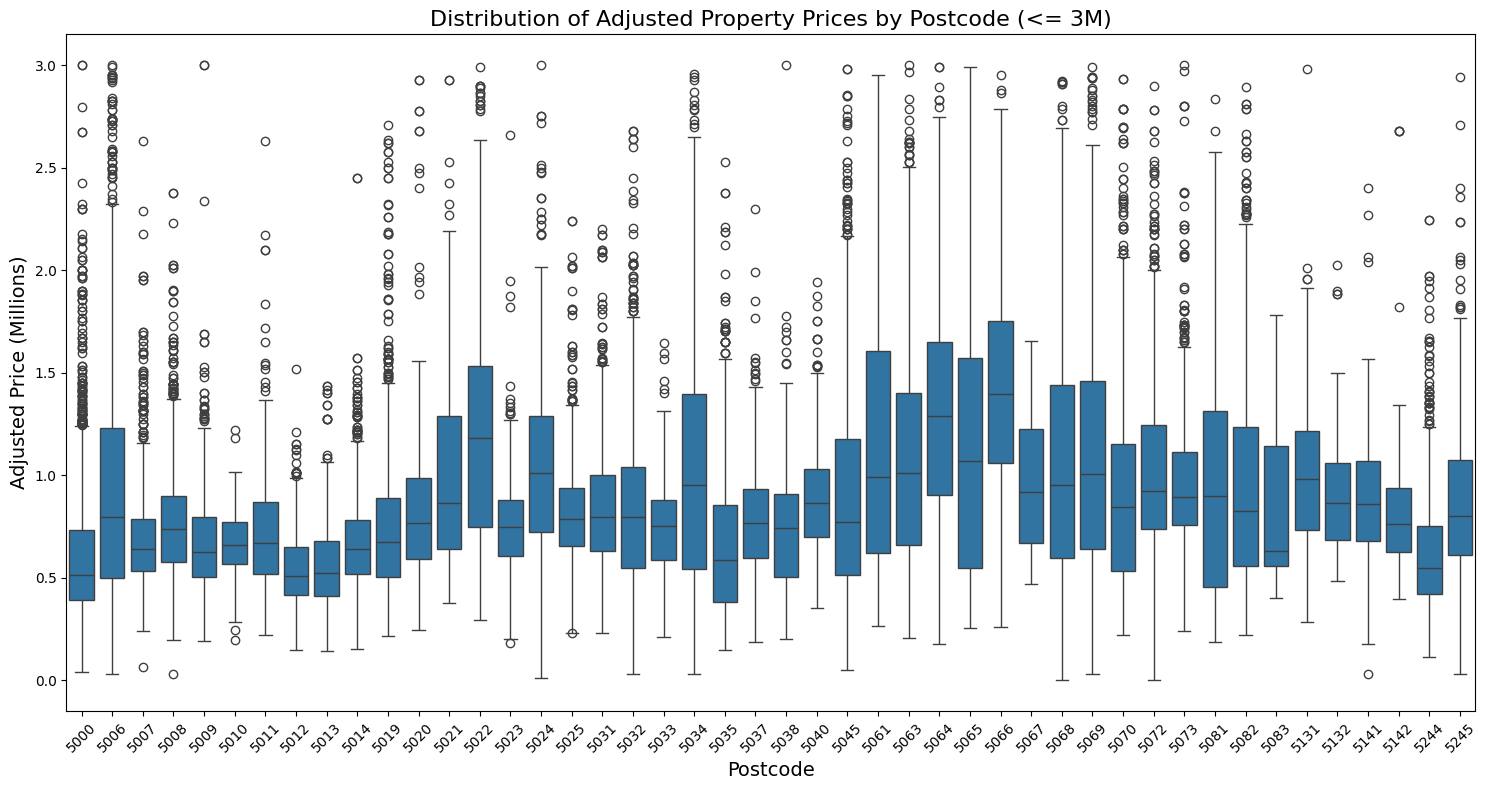

In [12]:
data['Price_Adjusted2024_M'] = data['Price_Adjusted2024'] / 1e6

data_filtered = data[data['Price_Adjusted2024_M'] <= 3]
data_filtered = data_filtered.sort_values('Postcode', ascending=True)

plt.figure(figsize=(15, 8))
sns.boxplot(data=data_filtered, x='Postcode', y='Price_Adjusted2024_M')
plt.xlabel("Postcode", fontsize=14)
plt.ylabel("Adjusted Price (Millions)", fontsize=14)
plt.title("Distribution of Adjusted Property Prices by Postcode (<= 3M)", fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

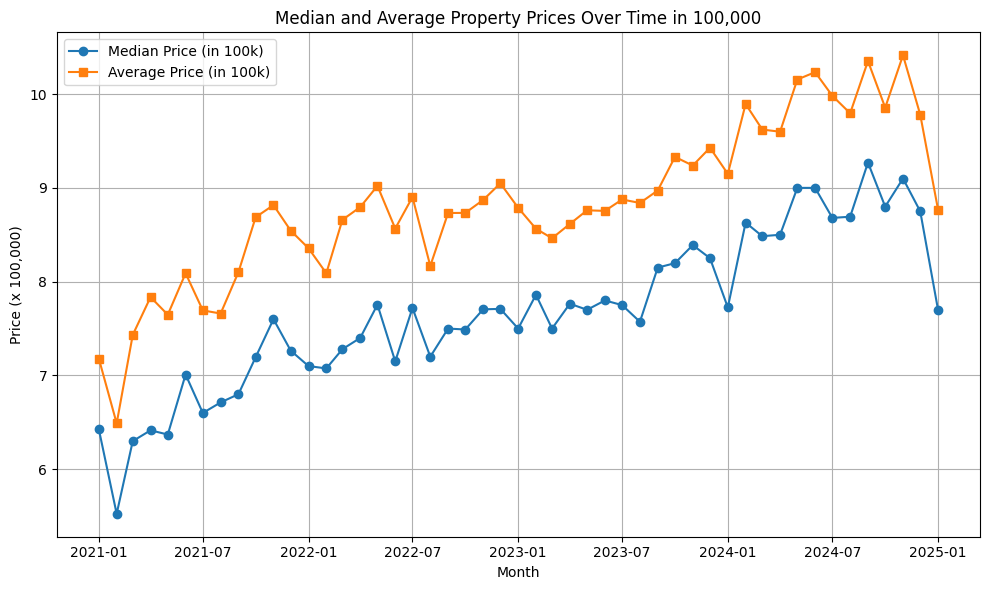

In [17]:
data['SoldDateDT'] = pd.to_datetime(data['SoldDate'])

mask = (data['SoldDateDT'] >= '2021-01-01')
df_filtered = data.loc[mask].copy()

df_filtered['PriceScaled'] = df_filtered['Price'] / 100000

df_filtered['Month'] = df_filtered['SoldDateDT'].dt.to_period('M')
grouped = df_filtered.groupby('Month')['PriceScaled'].agg(['median', 'mean']).reset_index()
grouped['Month'] = grouped['Month'].dt.to_timestamp()

plt.figure(figsize=(10, 6))
plt.plot(grouped['Month'], grouped['median'], marker='o', label='Median Price (in 100k)')
plt.plot(grouped['Month'], grouped['mean'], marker='s', label='Average Price (in 100k)')
plt.xlabel('Month')
plt.ylabel('Price (x 100,000)')
plt.title('Median and Average Property Prices Over Time in 100,000')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Feature set and target

In [13]:
features_to_use = [
    'City_encoded', 'Bed', 'Bath', 'Parking', 'Type_encoded', 
    'TotalRooms', 'SoldYear', 'SoldMonth'
]

In [14]:
features_to_use += list(postcode_dummies.columns) + list(city_dummies.columns) + list(type_dummies.columns) # one-hot encoding
print(features_to_use)

X = data[features_to_use]
y = data['Price_Adjusted2024'].values

print(f"Feature set shape: {X.shape}")
print(f"Target shape: {y.shape}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

['City_encoded', 'Bed', 'Bath', 'Parking', 'Type_encoded', 'TotalRooms', 'SoldYear', 'SoldMonth', 'postcode_5006', 'postcode_5007', 'postcode_5008', 'postcode_5009', 'postcode_5010', 'postcode_5011', 'postcode_5012', 'postcode_5013', 'postcode_5014', 'postcode_5019', 'postcode_5020', 'postcode_5021', 'postcode_5022', 'postcode_5023', 'postcode_5024', 'postcode_5025', 'postcode_5031', 'postcode_5032', 'postcode_5033', 'postcode_5034', 'postcode_5035', 'postcode_5037', 'postcode_5038', 'postcode_5040', 'postcode_5045', 'postcode_5061', 'postcode_5063', 'postcode_5064', 'postcode_5065', 'postcode_5066', 'postcode_5067', 'postcode_5068', 'postcode_5069', 'postcode_5070', 'postcode_5072', 'postcode_5073', 'postcode_5081', 'postcode_5082', 'postcode_5083', 'postcode_5131', 'postcode_5132', 'postcode_5141', 'postcode_5142', 'postcode_5244', 'postcode_5245', 'city_albert park', 'city_alberton', 'city_allenby gardens', 'city_angle park', 'city_ashford', 'city_athol park', 'city_auldana', 'city_

In [15]:
from xgboost import XGBRegressor

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# reducing skewness
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)


### Model building - hyperparameter tuning with GridSearchCV

In [16]:
param_grid = {
    'n_estimators': [500, 1000], # the number of trees 
    'learning_rate': [0.05, 0.1, 0.2], # prevents overfitting
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0], # 80% of the training data is being used to build each tree
    'colsample_bytree': [0.8, 1.0], # 80% of the features are sampled
}

xgb_model = XGBRegressor(random_state=42, objective='reg:squarederror')

grid_search = GridSearchCV(estimator=xgb_model,
                           param_grid=param_grid,
                           scoring='neg_root_mean_squared_error',
                           cv=3, # 3 fold cross-validation, model is trained on two, validated on third
                           verbose=1,
                           n_jobs=-1)

## Train

In [17]:
grid_search.fit(X_train, y_train_log)

print("Best parameters found: ", grid_search.best_params_)
print("Best (negative) RMSE from CV: ", grid_search.best_score_)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best parameters found:  {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 1000, 'subsample': 1.0}
Best (negative) RMSE from CV:  -0.2707092695067226


## Evaluate

In [18]:
best_model = grid_search.best_estimator_
y_pred_log = best_model.predict(X_test)
y_pred = np.expm1(y_pred_log)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nTest MSE: {mse:.2f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Test MAE: {mae:.2f}")
print(f"Test R²: {r2:.2f}")


Test MSE: 85584383997.77
Test RMSE: 292548.09
Test MAE: 163943.16
Test R²: 0.70


## Analysis

In [ ]:
# Compute residuals in millions
y_test_m = y_test / 1e6
y_pred_m = y_pred / 1e6

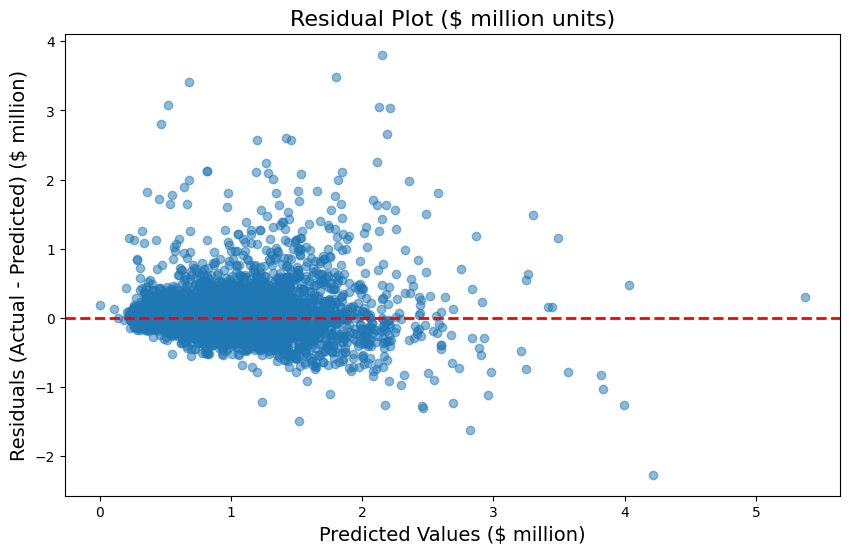

In [35]:
# actual value - predicted value comparision
residuals_m = y_test_m - y_pred_m

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_m, residuals_m, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Values ($ million)', fontsize=14)
plt.ylabel('Residuals (Actual - Predicted) ($ million)', fontsize=14)
plt.title('Residual Plot ($ million units)', fontsize=16)
plt.show()


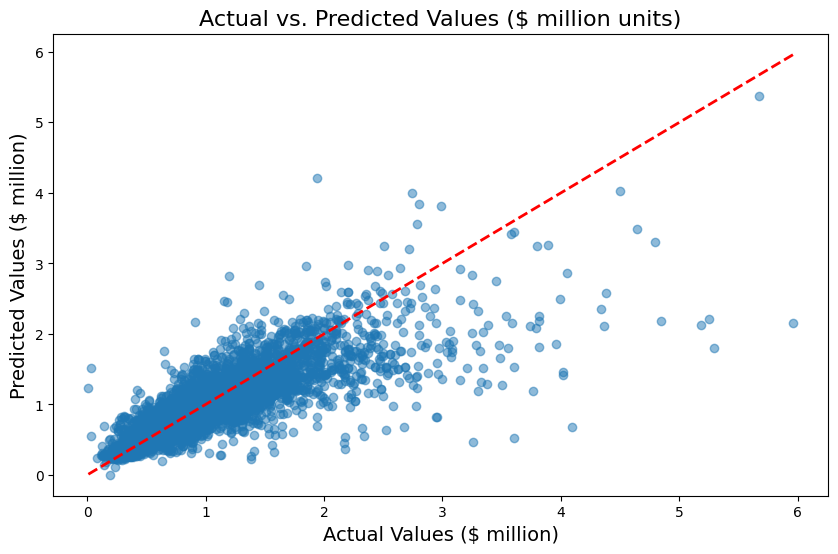

In [36]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_m, y_pred_m, alpha=0.5)
plt.plot([min(y_test_m), max(y_test_m)], [min(y_test_m), max(y_test_m)], color='red', linestyle='--', linewidth=2)
plt.xlabel('Actual Values ($ million)', fontsize=14)
plt.ylabel('Predicted Values ($ million)', fontsize=14)
plt.title('Actual vs. Predicted Values ($ million units)', fontsize=16)
plt.show()

In [42]:
importances = best_model.feature_importances_
features = X.columns
indices = np.argsort(importances)

# number of top features
top_n = 20

In [48]:
def plot_feature_importances_by_prefix(features, importances, prefix, top_n=10, 
                                       xlabel='Feature Importance', title=None, figsize=(10, 8)):

    mask = [feat.startswith(prefix) for feat in features]
    
    sel_features = np.array(features)[mask]
    sel_importances = np.array(importances)[mask]
    
    sorted_indices = np.argsort(sel_importances)[::-1]
    sorted_features = sel_features[sorted_indices]
    sorted_importances = sel_importances[sorted_indices]

    sorted_features = sorted_features[:top_n]
    sorted_importances = sorted_importances[:top_n]
    
    plt.figure(figsize=figsize)
    plt.barh(range(len(sorted_features)), sorted_importances, align='center', color='skyblue')
    plt.yticks(range(len(sorted_features)), sorted_features, fontsize=12)
    plt.xlabel(xlabel, fontsize=14)
    if title is None:
        title = f"Top {len(sorted_features)} Features with prefix '{prefix}'"
    plt.title(title, fontsize=16)
    plt.gca().invert_yaxis()  # Invert y-axis so that the highest importance is at the top.
    plt.tight_layout()
    return plt

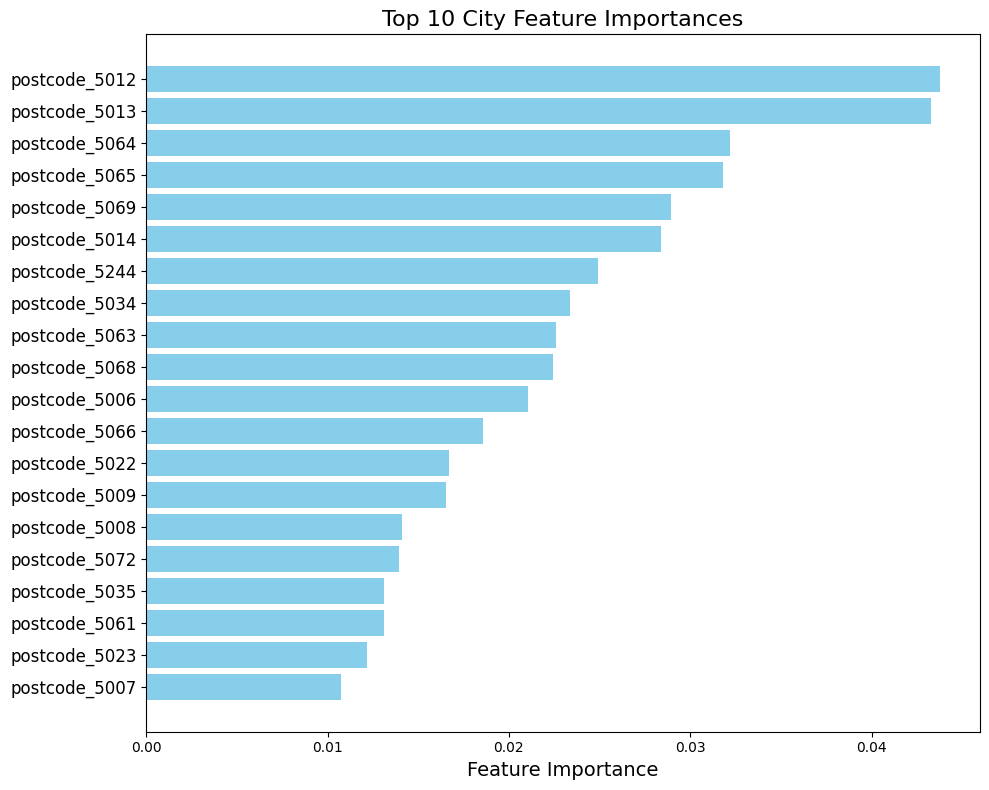

In [49]:
postcode_feature_importance_plt = plot_feature_importances_by_prefix(features, importances, prefix='postcode_', top_n=top_n,
                                   title="Top 10 City Feature Importances")
postcode_feature_importance_plt.show()

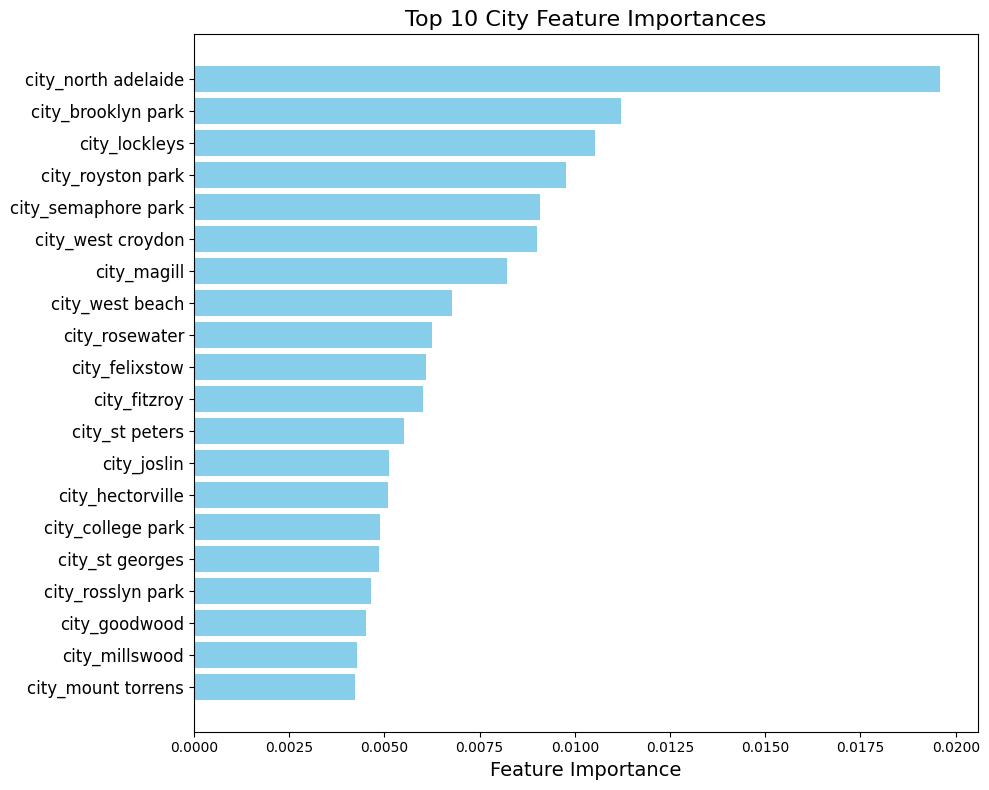

In [50]:
city_feature_importance_plt = plot_feature_importances_by_prefix(features, importances, prefix='city_', top_n=top_n,
                                   title="Top 10 City Feature Importances")
city_feature_importance_plt.show()

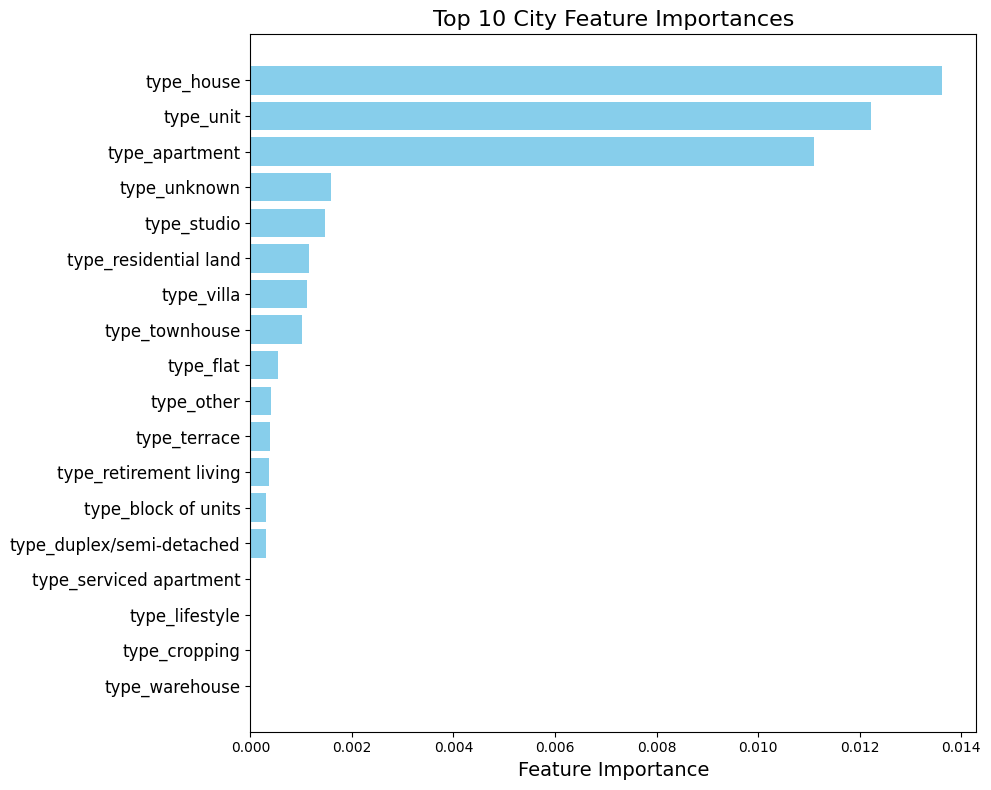

In [51]:
propertytype_feature_importance_plt = plot_feature_importances_by_prefix(features, importances, prefix='type', top_n=top_n,
                                   title="Top 10 City Feature Importances")
propertytype_feature_importance_plt.show()

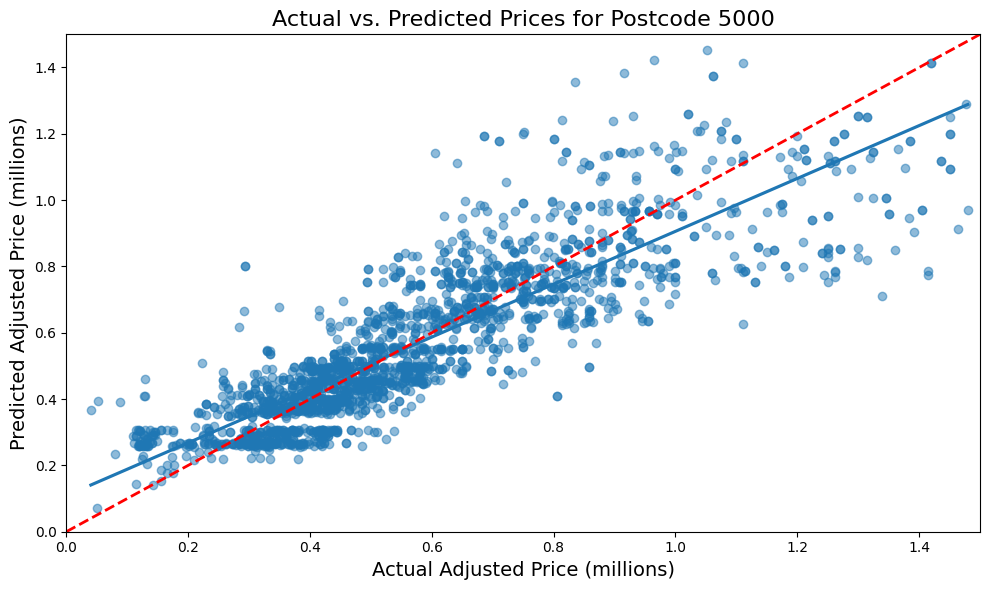

In [58]:
sample_postcode = "5000"

data_subset = data[data['Postcode'] == sample_postcode].copy()

# check that we have rows for the postcode
if data_subset.empty:
    raise ValueError(f"No data found for postcode {sample_postcode}")

X_subset = X.loc[data_subset.index]

X_subset_scaled = scaler.transform(X_subset)

# model was trained on a log-transformed target, so predictions need to be reversed
y_pred_log = best_model.predict(X_subset_scaled)
y_pred = np.expm1(y_pred_log)  # convert back to original scale

# actual target for this subset
y_actual = data_subset['Price_Adjusted2024'].values

# convert to million for better interpretation
y_pred_m = y_pred / 1e6
y_actual_m = y_actual / 1e6

# exclude outliers
mask = (y_actual_m <= 1.5) & (y_pred_m <= 1.5)
y_actual_m_filtered = y_actual_m[mask]
y_pred_m_filtered = y_pred_m[mask]

plt.figure(figsize=(10, 6))
sns.regplot(x=y_actual_m_filtered, y=y_pred_m_filtered, ci=None, scatter_kws={'alpha': 0.5})

plt.plot([0, 1.5], [0, 1.5], color='red', linestyle='--', linewidth=2)

plt.xlabel("Actual Adjusted Price (millions)", fontsize=14)
plt.ylabel("Predicted Adjusted Price (millions)", fontsize=14)
plt.title(f"Actual vs. Predicted Prices for Postcode {sample_postcode}", fontsize=16)
plt.xlim(0, 1.5)
plt.ylim(0, 1.5)
plt.tight_layout()
plt.show()

# Prediction check

In [75]:
# sample_postcode = "5000"  
input_city = "adelaide"      
# input_type = "apartment"
bed = 1
bath = 1
# parking = 5
# total_rooms = bed + bath + parking
# sold_year = 2024
# sold_month = 12

# For the encoded features (if using LabelEncoder for core features)
# encoded_city = city_encoder.transform([input_city])[0]
# encoded_type = type_encoder.transform([input_type])[0]

# Build a DataFrame with the same columns as your training data.
all_features = X.columns  # e.g., 250 columns from training
sample_data = pd.DataFrame(np.zeros((1, len(all_features))), columns=all_features)

# Fill in the known non-dummy features.
# sample_data['City_encoded'] = encoded_city
sample_data['Bed'] = bed
sample_data['Bath'] = bath
# sample_data['Parking'] = parking
# sample_data['Type_encoded'] = encoded_type
# sample_data['TotalRooms'] = total_rooms
# sample_data['SoldYear'] = sold_year
# sample_data['SoldMonth'] = sold_month

# Now, handle one-hot encoded columns for postcode, city, and type.



# Build the corresponding dummy column name (as created during training).
postcode_column = f"postcode_{sample_postcode}"
if postcode_column in sample_data.columns:
    sample_data[postcode_column] = 1  # Set the dummy flag.

# --- City (one-hot encoded) ---
sample_city_dummy = f"city_{input_city}"
if sample_city_dummy in sample_data.columns:
    sample_data[sample_city_dummy] = 1

# # --- Property Type (one-hot encoded) ---
# sample_type_dummy = f"type_{input_type}"
# if sample_type_dummy in sample_data.columns:
#     sample_data[sample_type_dummy] = 1

# Display the sample input DataFrame before scaling.
print("Sample DataFrame before scaling:")
print(sample_data)

# Apply the scaler that was used during training.
sample_input_scaled = scaler.transform(sample_data)

# Make a prediction using your trained model.
sample_prediction_log = best_model.predict(sample_input_scaled)[0]
# Reverse the log transformation to get the actual price.
sample_prediction_price = np.expm1(sample_prediction_log)

print(f"Prediction: Bed={bed}, Bath={bath} in postcode '{sample_postcode}': ${sample_prediction_price:,.2f}")

Sample DataFrame before scaling:
   City_encoded  Bed  Bath  Parking  Type_encoded  TotalRooms  SoldYear  \
0           0.0    1     1      0.0           0.0         0.0       0.0   

   SoldMonth  postcode_5006  postcode_5007  ...  type_residential land  \
0        0.0            0.0            0.0  ...                    0.0   

   type_retirement living  type_serviced apartment  type_studio  type_terrace  \
0                     0.0                      0.0          0.0           0.0   

   type_townhouse  type_unit  type_unknown  type_villa  type_warehouse  
0             0.0        0.0           0.0         0.0             0.0  

[1 rows x 250 columns]
Prediction: Bed=1, Bath=1 in postcode '5000': $192,410.36


## Export (Optional)

In [74]:
import joblib
import os

model_dir = "../model"

if not os.path.exists(model_dir):
    os.makedirs(model_dir)

model_path = os.path.join(model_dir, "best_model.pkl")
joblib.dump(best_model, model_path)

model_preprocess_dir = "../model/preprocess"

if not os.path.exists(model_preprocess_dir):
    os.makedirs(model_preprocess_dir)
    
# export preprocessing objects
scaler_path = os.path.join(model_preprocess_dir, "scaler.pkl")
city_encoder_path = os.path.join(model_preprocess_dir, "city_encoder.pkl")
type_encoder_path = os.path.join(model_preprocess_dir, "type_encoder.pkl")
pipeline_path = os.path.join(model_preprocess_dir, "model_pipeline.pkl")

joblib.dump(scaler, scaler_path)
joblib.dump(city_encoder, city_encoder_path)
joblib.dump(type_encoder, type_encoder_path)

['../model/preprocess/type_encoder.pkl']